<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº6
#### Jeremias Martin Pantozzi


### Introducción y Objetivos
Este notebook tiene como objetivo analizar, caracterizar y simular el comportamiento en frecuencia de cuatro sistemas discretos Lineales e Invariantes en el Tiempo (LTI), basados en sus ecuaciones en diferencias. 

A través de este desarrollo se busca:
* Obtener la **Función de Transferencia** $T(z)$ en el dominio Z.
* Determinar analíticamente la **Respuesta en Frecuencia** (Módulo y Fase).
* Validar de forma práctica los resultados mediante simulaciones numéricas.

### Marco Teórico

#### Función de Transferencia $T(z)$
A partir de la ecuación en diferencias de un sistema LTI, aplicamos la **propiedad de desplazamiento temporal** de la Transformada Z:
$$\mathcal{Z}\{x(n-k)\} = z^{-k}X(z)$$

La función de transferencia se define como la relación entre la salida y la entrada en el dominio complejo $z$:
$$T(z) = \frac{Y(z)}{X(z)}$$

#### Respuesta en Frecuencia
Para evaluar el comportamiento del sistema ante diferentes componentes frecuenciales, se analiza la función de transferencia sobre el **círculo unitario** mediante la sustitución:
$$z = e^{j\omega}$$

Donde $\omega$ es la frecuencia angular digital en radianes por muestra ($\omega \in [0, \pi]$). Esto nos permite descomponer el sistema en:
* **Respuesta de Magnitud:** $|T(e^{j\omega})|$, que describe cómo el filtro atenúa o amplifica cada frecuencia.
* **Respuesta de Fase:** $\angle T(e^{j\omega})$, que describe el desfase o retraso temporal que sufre cada componente frecuencial al atravesar el sistema.

## Desarrollo y Resultados

### Sistema a: $y(n) = x(n - 3) + x(n - 2) + x(n - 1) + x(n)$

In [5]:
from IPython.display import display, HTML

# Usamos un objeto embebido nativo pasándole un truco de bypass
html_code = '<embed src="TS6_A.PDF" type="application/pdf" width="100%" height="600px" />'
display(HTML(html_code))

C:\Users\jerem\AppData\Local\Temp\ipykernel_10976\1905917182.py:37: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()


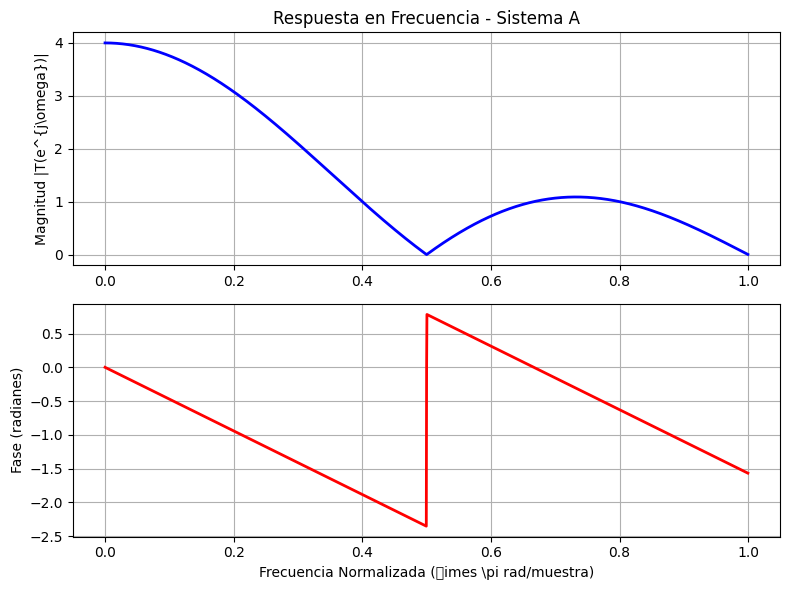

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


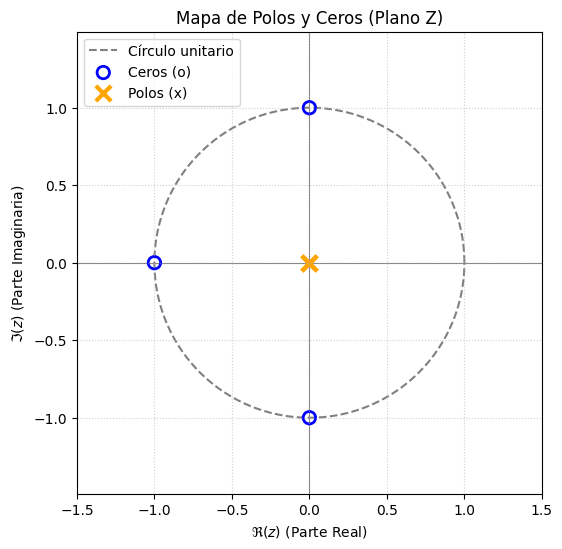

In [11]:
#%% Librerias
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

#%% Definiciones
#Los coeficientes del sistema
b = [1, 1, 1, 1]  # Coeficientes que multiplican a las x(n)
a = [1]           # Coeficiente que multiplica a y(n)

# Calculamos la respuesta en frecuencia
w, h = signal.freqz(b, a, worN=2000)

# Calculamos las raíces para el mapa de polos y ceros
ceros = np.roots(b)
polos = np.roots(a)

if len(a) == 1 and a[0] == 1:
    polos = np.zeros(len(b) - 1)  # Crea un array de ceros reales [0, 0, 0]
else:
    polos = np.roots(a)

#%% Graficamos Módulo y Fase
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

# Gráfico de Magnitud
ax1.plot(w / np.pi, np.abs(h), 'b', linewidth=2)
ax1.set_title('Respuesta en Frecuencia - Sistema A')
ax1.set_ylabel('Magnitud |T(e^{j\omega})|')
ax1.grid(True)

# Gráfico de Fase
ax2.plot(w / np.pi, np.angle(h), 'r', linewidth=2)
ax2.set_xlabel('Frecuencia Normalizada (\times \pi rad/muestra)')
ax2.set_ylabel('Fase (radianes)')
ax2.grid(True)
plt.tight_layout()

# Mapa de Polos y Ceros (Plano Z)
fig2, ax3 = plt.subplots(figsize=(6, 6))

# Dibujamos el círculo unitario punteado al fondo (zorder=1)
theta = np.linspace(0, 2 * np.pi, 200)
ax3.plot(np.cos(theta), np.sin(theta), color='gray', linestyle='--', label='Círculo unitario', zorder=1)

# Dibujamos los ejes cartesianos al fondo (zorder=1)
ax3.axhline(0, color='gray', linewidth=0.8, zorder=1)
ax3.axvline(0, color='gray', linewidth=0.8, zorder=1)

# Graficamos los Ceros adelante (zorder=2)
if len(ceros) > 0:
    ax3.scatter(np.real(ceros), np.imag(ceros), s=80, facecolors='none', 
                edgecolors='blue', linewidth=2, label='Ceros (o)')

# Graficamos los Polos al frente de todo (zorder=3) y más grandes (s=120)
if len(polos) > 0:
    ax3.scatter(np.real(polos), np.imag(polos), s=120, marker='x', 
                color='orange', linewidth=3, label='Polos (x)')

# Ajustes estéticos para que sea idéntico al plano Z teórico
ax3.set_title('Mapa de Polos y Ceros (Plano Z)')
ax3.set_xlabel('$\\Re(z)$ (Parte Real)')
ax3.set_ylabel('$\\Im(z)$ (Parte Imaginaria)')
ax3.grid(True, which='both', linestyle=':', alpha=0.6, zorder=1)

# Forzamos la relación de aspecto 1:1 para que el círculo no se vea ovalado
ax3.axis('equal') 
ax3.set_xlim([-1.5, 1.5])
ax3.set_ylim([-1.5, 1.5])
ax3.legend(loc='upper left')

plt.show()

### Sistema b: $y(n) = x(n-4) + x(n - 3) + x(n - 2) + x(n - 1) + x(n)$

In [14]:
from IPython.display import display, HTML

# Usamos un objeto embebido nativo pasándole un truco de bypass
html_code = '<embed src="TS6_B.PDF" type="application/pdf" width="100%" height="600px" />'
display(HTML(html_code))

C:\Users\jerem\AppData\Local\Temp\ipykernel_10976\2421341594.py:37: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()


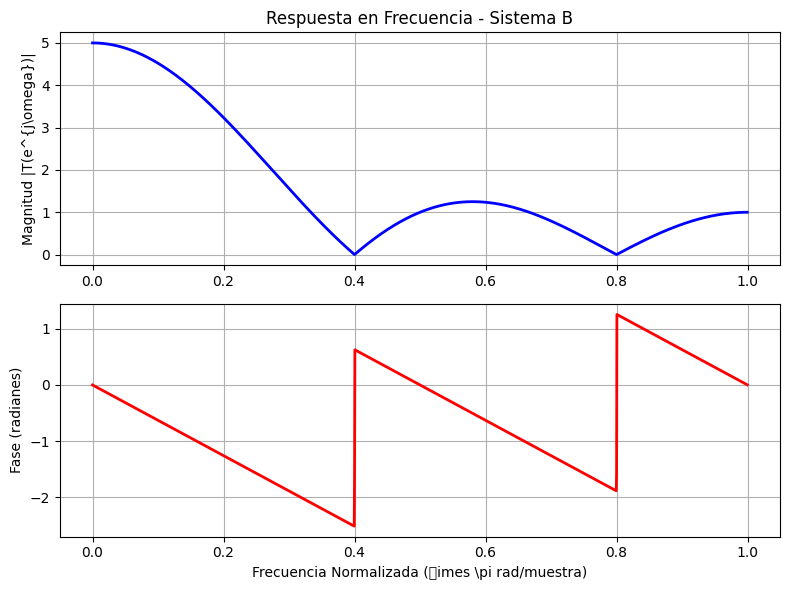

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


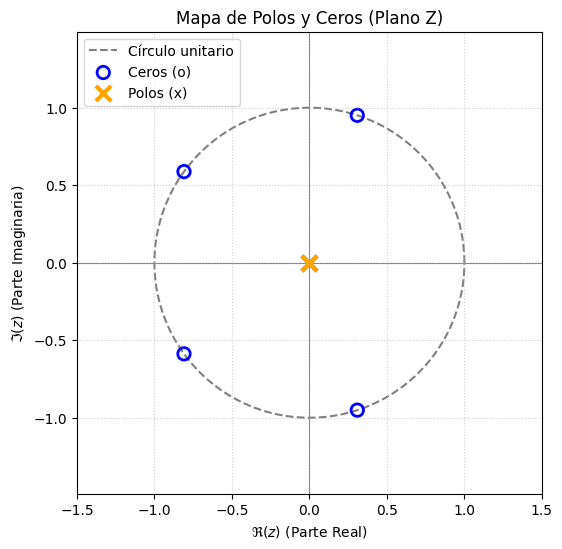

In [12]:
#%% Librerias
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

#%% Definiciones
#Los coeficientes del sistema
b = [1, 1, 1, 1,1]  # Coeficientes que multiplican a las x(n)
a = [1]           # Coeficiente que multiplica a y(n)

# Calculamos la respuesta en frecuencia
w, h = signal.freqz(b, a, worN=2000)

# Calculamos las raíces para el mapa de polos y ceros
ceros = np.roots(b)
polos = np.roots(a)

if len(a) == 1 and a[0] == 1:
    polos = np.zeros(len(b) - 1)  # Crea un array de ceros reales [0, 0, 0]
else:
    polos = np.roots(a)

#%% Graficamos Módulo y Fase
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

# Gráfico de Magnitud
ax1.plot(w / np.pi, np.abs(h), 'b', linewidth=2)
ax1.set_title('Respuesta en Frecuencia - Sistema B')
ax1.set_ylabel('Magnitud |T(e^{j\omega})|')
ax1.grid(True)

# Gráfico de Fase
ax2.plot(w / np.pi, np.angle(h), 'r', linewidth=2)
ax2.set_xlabel('Frecuencia Normalizada (\times \pi rad/muestra)')
ax2.set_ylabel('Fase (radianes)')
ax2.grid(True)
plt.tight_layout()

# Mapa de Polos y Ceros (Plano Z)
fig2, ax3 = plt.subplots(figsize=(6, 6))

# Dibujamos el círculo unitario punteado al fondo (zorder=1)
theta = np.linspace(0, 2 * np.pi, 200)
ax3.plot(np.cos(theta), np.sin(theta), color='gray', linestyle='--', label='Círculo unitario', zorder=1)

# Dibujamos los ejes cartesianos al fondo (zorder=1)
ax3.axhline(0, color='gray', linewidth=0.8, zorder=1)
ax3.axvline(0, color='gray', linewidth=0.8, zorder=1)

# Graficamos los Ceros adelante (zorder=2)
if len(ceros) > 0:
    ax3.scatter(np.real(ceros), np.imag(ceros), s=80, facecolors='none', 
                edgecolors='blue', linewidth=2, label='Ceros (o)')

# Graficamos los Polos al frente de todo (zorder=3) y más grandes (s=120)
if len(polos) > 0:
    ax3.scatter(np.real(polos), np.imag(polos), s=120, marker='x', 
                color='orange', linewidth=3, label='Polos (x)')

# Ajustes estéticos para que sea idéntico al plano Z teórico
ax3.set_title('Mapa de Polos y Ceros (Plano Z)')
ax3.set_xlabel('$\\Re(z)$ (Parte Real)')
ax3.set_ylabel('$\\Im(z)$ (Parte Imaginaria)')
ax3.grid(True, which='both', linestyle=':', alpha=0.6, zorder=1)

# Forzamos la relación de aspecto 1:1 para que el círculo no se vea ovalado
ax3.axis('equal') 
ax3.set_xlim([-1.5, 1.5])
ax3.set_ylim([-1.5, 1.5])
ax3.legend(loc='upper left')

plt.show()

### Sistema c: $y(n) = - x(n - 1) + x(n)$

In [13]:
from IPython.display import display, HTML

# Usamos un objeto embebido nativo pasándole un truco de bypass
html_code = '<embed src="TS6_C.PDF" type="application/pdf" width="100%" height="600px" />'
display(HTML(html_code))

C:\Users\jerem\AppData\Local\Temp\ipykernel_10976\346920776.py:37: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()


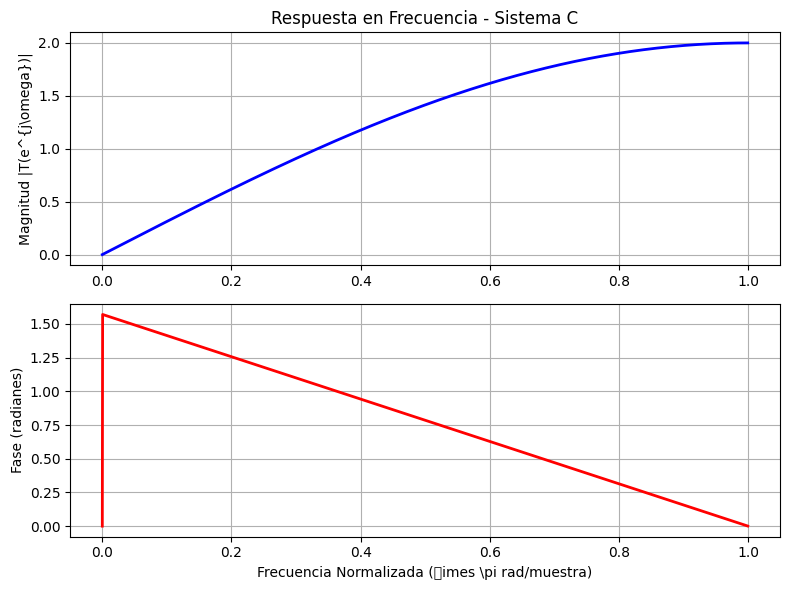

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


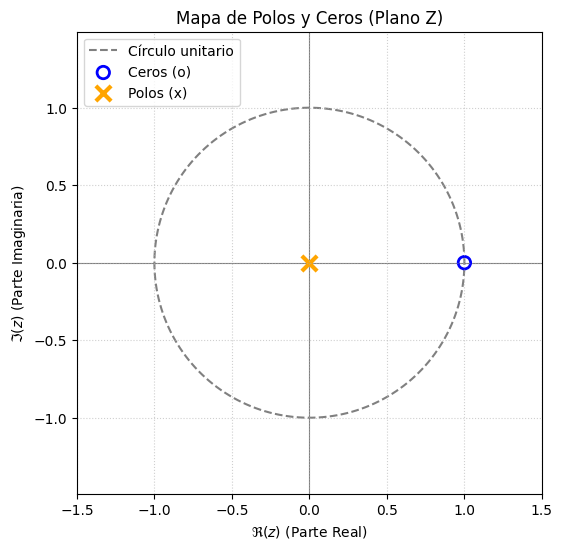

In [15]:
#%% Librerias
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

#%% Definiciones
#Los coeficientes del sistema
b = [1, -1]  # Coeficientes que multiplican a las x(n)
a = [1]           # Coeficiente que multiplica a y(n)

# Calculamos la respuesta en frecuencia
w, h = signal.freqz(b, a, worN=2000)

# Calculamos las raíces para el mapa de polos y ceros
ceros = np.roots(b)
polos = np.roots(a)

if len(a) == 1 and a[0] == 1:
    polos = np.zeros(len(b) - 1)  # Crea un array de ceros reales [0, 0, 0]
else:
    polos = np.roots(a)

#%% Graficamos Módulo y Fase
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

# Gráfico de Magnitud
ax1.plot(w / np.pi, np.abs(h), 'b', linewidth=2)
ax1.set_title('Respuesta en Frecuencia - Sistema C')
ax1.set_ylabel('Magnitud |T(e^{j\omega})|')
ax1.grid(True)

# Gráfico de Fase
ax2.plot(w / np.pi, np.angle(h), 'r', linewidth=2)
ax2.set_xlabel('Frecuencia Normalizada (\times \pi rad/muestra)')
ax2.set_ylabel('Fase (radianes)')
ax2.grid(True)
plt.tight_layout()

# Mapa de Polos y Ceros (Plano Z)
fig2, ax3 = plt.subplots(figsize=(6, 6))

# Dibujamos el círculo unitario punteado al fondo (zorder=1)
theta = np.linspace(0, 2 * np.pi, 200)
ax3.plot(np.cos(theta), np.sin(theta), color='gray', linestyle='--', label='Círculo unitario', zorder=1)

# Dibujamos los ejes cartesianos al fondo (zorder=1)
ax3.axhline(0, color='gray', linewidth=0.8, zorder=1)
ax3.axvline(0, color='gray', linewidth=0.8, zorder=1)

# Graficamos los Ceros adelante (zorder=2)
if len(ceros) > 0:
    ax3.scatter(np.real(ceros), np.imag(ceros), s=80, facecolors='none', 
                edgecolors='blue', linewidth=2, label='Ceros (o)')

# Graficamos los Polos al frente de todo (zorder=3) y más grandes (s=120)
if len(polos) > 0:
    ax3.scatter(np.real(polos), np.imag(polos), s=120, marker='x', 
                color='orange', linewidth=3, label='Polos (x)')

# Ajustes estéticos para que sea idéntico al plano Z teórico
ax3.set_title('Mapa de Polos y Ceros (Plano Z)')
ax3.set_xlabel('$\\Re(z)$ (Parte Real)')
ax3.set_ylabel('$\\Im(z)$ (Parte Imaginaria)')
ax3.grid(True, which='both', linestyle=':', alpha=0.6, zorder=1)

# Forzamos la relación de aspecto 1:1 para que el círculo no se vea ovalado
ax3.axis('equal') 
ax3.set_xlim([-1.5, 1.5])
ax3.set_ylim([-1.5, 1.5])
ax3.legend(loc='upper left')

plt.show()

### Sistema d: $y(n) = x(n) - x(n-2)$

In [16]:
from IPython.display import display, HTML

# Usamos un objeto embebido nativo pasándole un truco de bypass
html_code = '<embed src="TS6_D.PDF" type="application/pdf" width="100%" height="600px" />'
display(HTML(html_code))

C:\Users\jerem\AppData\Local\Temp\ipykernel_10976\1702816689.py:37: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()


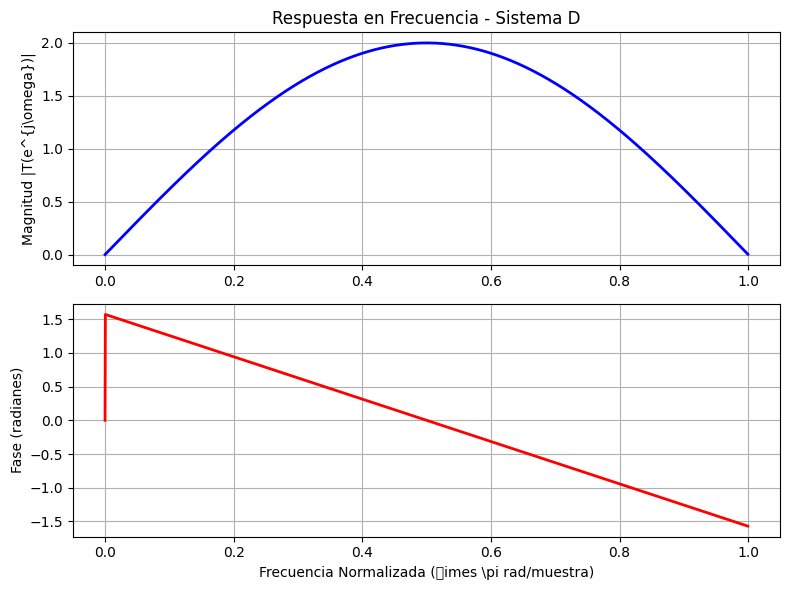

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


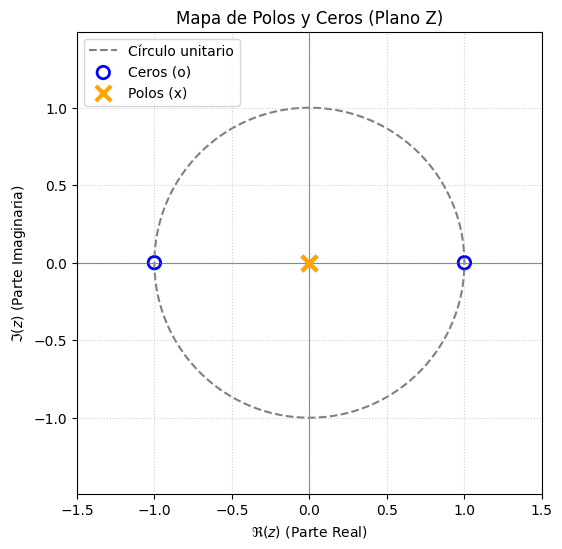

In [17]:
#%% Librerias
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

#%% Definiciones
#Los coeficientes del sistema
b = [1,0, -1]  # Coeficientes que multiplican a las x(n)
a = [1]           # Coeficiente que multiplica a y(n)

# Calculamos la respuesta en frecuencia
w, h = signal.freqz(b, a, worN=2000)

# Calculamos las raíces para el mapa de polos y ceros
ceros = np.roots(b)
polos = np.roots(a)

if len(a) == 1 and a[0] == 1:
    polos = np.zeros(len(b) - 1)  # Crea un array de ceros reales [0, 0, 0]
else:
    polos = np.roots(a)

#%% Graficamos Módulo y Fase
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

# Gráfico de Magnitud
ax1.plot(w / np.pi, np.abs(h), 'b', linewidth=2)
ax1.set_title('Respuesta en Frecuencia - Sistema D')
ax1.set_ylabel('Magnitud |T(e^{j\omega})|')
ax1.grid(True)

# Gráfico de Fase
ax2.plot(w / np.pi, np.angle(h), 'r', linewidth=2)
ax2.set_xlabel('Frecuencia Normalizada (\times \pi rad/muestra)')
ax2.set_ylabel('Fase (radianes)')
ax2.grid(True)
plt.tight_layout()

# Mapa de Polos y Ceros (Plano Z)
fig2, ax3 = plt.subplots(figsize=(6, 6))

# Dibujamos el círculo unitario punteado al fondo (zorder=1)
theta = np.linspace(0, 2 * np.pi, 200)
ax3.plot(np.cos(theta), np.sin(theta), color='gray', linestyle='--', label='Círculo unitario', zorder=1)

# Dibujamos los ejes cartesianos al fondo (zorder=1)
ax3.axhline(0, color='gray', linewidth=0.8, zorder=1)
ax3.axvline(0, color='gray', linewidth=0.8, zorder=1)

# Graficamos los Ceros adelante (zorder=2)
if len(ceros) > 0:
    ax3.scatter(np.real(ceros), np.imag(ceros), s=80, facecolors='none', 
                edgecolors='blue', linewidth=2, label='Ceros (o)')

# Graficamos los Polos al frente de todo (zorder=3) y más grandes (s=120)
if len(polos) > 0:
    ax3.scatter(np.real(polos), np.imag(polos), s=120, marker='x', 
                color='orange', linewidth=3, label='Polos (x)')

# Ajustes estéticos para que sea idéntico al plano Z teórico
ax3.set_title('Mapa de Polos y Ceros (Plano Z)')
ax3.set_xlabel('$\\Re(z)$ (Parte Real)')
ax3.set_ylabel('$\\Im(z)$ (Parte Imaginaria)')
ax3.grid(True, which='both', linestyle=':', alpha=0.6, zorder=1)

# Forzamos la relación de aspecto 1:1 para que el círculo no se vea ovalado
ax3.axis('equal') 
ax3.set_xlim([-1.5, 1.5])
ax3.set_ylim([-1.5, 1.5])
ax3.legend(loc='upper left')

plt.show()
